# Notebook 04 — CNN Bônus: MobileNetV2 + Grad-CAM

Pré-requisito: notebooks 01, 02, 03 já executados.

Este notebook cobre:
- Transfer learning com MobileNetV2 (backbone ImageNet congelado)
- Fine-tuning parcial dos últimos 30 layers
- Grad-CAM para visualização de ativações
- Comparação direta com o pipeline clássico

## Seção 1 — Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)
from pathlib import Path
import json

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

SEGMENTED_DIR = Path('../data/segmented')
OUTPUT_DIR = Path('../outputs')
FIGURES_DIR = OUTPUT_DIR / 'figures'
IMG_SIZE = (224, 224)

CLASSES = ['fresh_apple', 'rotten_apple', 'fresh_banana', 'rotten_banana', 'fresh_orange', 'rotten_orange']
N_CLASSES = len(CLASSES)
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASSES)}

print(f'TensorFlow: {tf.__version__}')
print(f'GPUs disponíveis: {len(tf.config.list_physical_devices("GPU"))}')


TensorFlow: 2.15.0
GPUs disponíveis: 0


## Seção 2 — Preparação do Dataset

In [2]:
all_paths, all_labels = [], []
for cls in CLASSES:
    cls_dir = SEGMENTED_DIR / cls
    if not cls_dir.exists():
        print(f'AVISO: {cls_dir} não existe.')
        continue
    imgs = list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.png'))
    for p in imgs:
        all_paths.append(str(p))
        all_labels.append(CLASS_TO_IDX[cls])

all_labels = np.array(all_labels)
all_paths  = np.array(all_paths)

idx = np.arange(len(all_paths))
idx_trainval, idx_test = train_test_split(idx, test_size=0.15,
                                           stratify=all_labels, random_state=SEED)
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=0.15/0.85, stratify=all_labels[idx_trainval], random_state=SEED
)

paths_train, labels_train = all_paths[idx_train], all_labels[idx_train]
paths_val,   labels_val   = all_paths[idx_val],   all_labels[idx_val]
paths_test,  labels_test  = all_paths[idx_test],  all_labels[idx_test]

print(f'Treino: {len(paths_train)} | Val: {len(paths_val)} | Teste: {len(paths_test)}')

Treino: 840 | Val: 180 | Teste: 180


In [3]:
def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = preprocess_input(img)
    return img, label


def make_dataset(paths, labels, batch_size=32, shuffle=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=SEED)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (
            tf.image.random_flip_left_right(
                tf.image.random_brightness(x, 0.1), seed=SEED
            ), y
        ), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


BATCH_SIZE = 32
train_ds = make_dataset(paths_train, labels_train, BATCH_SIZE, shuffle=True, augment=True)
val_ds   = make_dataset(paths_val,   labels_val,   BATCH_SIZE)
test_ds  = make_dataset(paths_test,  labels_test,  BATCH_SIZE)

print('Datasets criados.')

Datasets criados.


## Seção 3 — Arquitetura MobileNetV2

In [4]:
# === REQUISITO BONUS: transfer learning com MobileNetV2 ===
def build_model(trainable_base=False):
    base_model = MobileNetV2(weights='imagenet', include_top=False,
                              input_shape=(224, 224, 3))
    base_model.trainable = trainable_base

    inputs = tf.keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    outputs = Dense(N_CLASSES, activation='softmax')(x)

    return Model(inputs, outputs)


model = build_model(trainable_base=False)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()



Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 dense_1 (Dense)             (None, 6)                 774 

## Seção 4 — Treinamento

In [5]:
callbacks_phase1 = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss', verbose=1),
]

print('=== Fase 1: Cabeça apenas (backbone congelado) ===')
history1 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=20, callbacks=callbacks_phase1, verbose=1
)
print(f'Fase 1 concluída. Val accuracy final: {max(history1.history["val_accuracy"]):.4f}')

=== Fase 1: Cabeça apenas (backbone congelado) ===
Epoch 1/20


27/27 [==============================] - 10s 306ms/step - loss: 0.6938 - accuracy: 0.7643 - val_loss: 0.2179 - val_accuracy: 0.9444 - lr: 0.0010
Epoch 2/20
27/27 [==============================] - 7s 266ms/step - loss: 0.1561 - accuracy: 0.9512 - val_loss: 0.1992 - val_accuracy: 0.9389 - lr: 0.0010
Epoch 3/20
27/27 [==============================] - 7s 273ms/step - loss: 0.1241 - accuracy: 0.9583 - val_loss: 0.1479 - val_accuracy: 0.9611 - lr: 0.0010
Epoch 4/20
27/27 [==============================] - 8s 279ms/step - loss: 0.0755 - accuracy: 0.9762 - val_loss: 0.1362 - val_accuracy: 0.9722 - lr: 0.0010
Epoch 5/20
27/27 [==============================] - 8s 278ms/step - loss: 0.0563 - accuracy: 0.9845 - val_loss: 0.1448 - val_accuracy: 0.9722 - lr: 0.0010
Epoch 6/20
27/27 [==============================] - 7s 263ms/step - loss: 0.0525 - accuracy: 0.9810 - val_loss: 0.1503 - val_accuracy: 0.9611 - lr: 0.0010
Epoch 7/20
27/27

In [6]:
base_model = model.layers[1]  # MobileNetV2 é o segundo layer
base_model.trainable = True
# habilita gradientes em todos os layers do backbone antes de congelar seletivamente

# Congelar todos exceto os últimos 30
for layer in base_model.layers[:-30]:
    # congela os primeiros layers (features genericas como bordas e texturas simples)
    layer.trainable = False
    # apenas os ultimos 30 layers ficam treinaveis: features de alto nivel mais especificas

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Layers treináveis no backbone: {trainable_count}/{len(base_model.layers)}')

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss', verbose=1),
]

print('=== Fase 2: Fine-tuning (últimos 30 layers) ===')
history2 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=10, callbacks=callbacks_phase2, verbose=1
)
print(f'Fase 2 concluída. Val accuracy final: {max(history2.history["val_accuracy"]):.4f}')

Layers treináveis no backbone: 30/154
=== Fase 2: Fine-tuning (últimos 30 layers) ===
Epoch 1/10
27/27 [==============================] - 12s 326ms/step - loss: 0.1157 - accuracy: 0.9548 - val_loss: 0.2325 - val_accuracy: 0.9444 - lr: 1.0000e-04
Epoch 2/10
27/27 [==============================] - 9s 317ms/step - loss: 0.1104 - accuracy: 0.9571 - val_loss: 0.1558 - val_accuracy: 0.9611 - lr: 1.0000e-04
Epoch 3/10
27/27 [==============================] - 8s 303ms/step - loss: 0.0713 - accuracy: 0.9750 - val_loss: 0.1742 - val_accuracy: 0.9389 - lr: 1.0000e-04
Epoch 4/10
27/27 [==============================] - 8s 301ms/step - loss: 0.0575 - accuracy: 0.9821 - val_loss: 0.1611 - val_accuracy: 0.9778 - lr: 1.0000e-04
Epoch 5/10
27/27 [==============================] - 8s 298ms/step - loss: 0.0217 - accuracy: 0.9917 - val_loss: 0.1268 - val_accuracy: 0.9722 - lr: 1.0000e-04
Epoch 6/10
27/27 [==============================] - 8s 299ms/step - loss: 0.0099 - accuracy: 0.9976 - val_loss: 0.1203

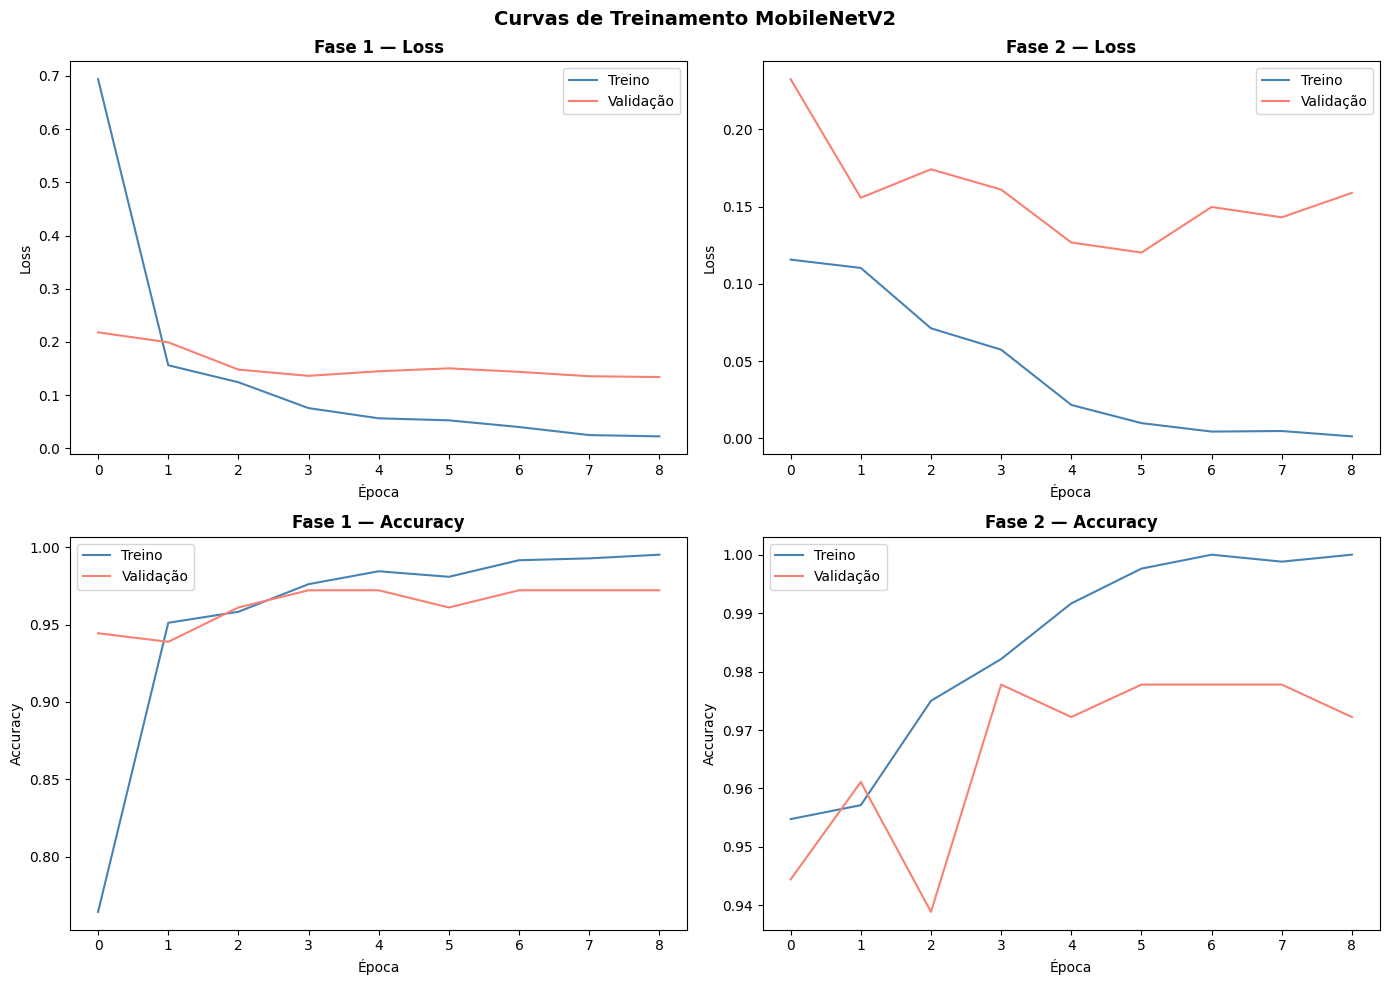

In [7]:
# Curvas de treinamento
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, (hist, phase) in enumerate([(history1, 'Fase 1'), (history2, 'Fase 2')]):
    axes[0, i].plot(hist.history['loss'], label='Treino', color='steelblue')
    axes[0, i].plot(hist.history['val_loss'], label='Validação', color='salmon')
    axes[0, i].set_title(f'{phase} — Loss', fontweight='bold')
    axes[0, i].set_xlabel('Época')
    axes[0, i].set_ylabel('Loss')
    axes[0, i].legend()

    axes[1, i].plot(hist.history['accuracy'], label='Treino', color='steelblue')
    axes[1, i].plot(hist.history['val_accuracy'], label='Validação', color='salmon')
    axes[1, i].set_title(f'{phase} — Accuracy', fontweight='bold')
    axes[1, i].set_xlabel('Época')
    axes[1, i].set_ylabel('Accuracy')
    axes[1, i].legend()

plt.suptitle('Curvas de Treinamento MobileNetV2', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cnn_training_curves.png', bbox_inches='tight', dpi=150)
plt.show()

## Seção 5 — Avaliação no Test Set

=== MobileNetV2 — Test Set ===
Accuracy:         0.9833
Precision (macro):0.9842
Recall (macro):   0.9833
F1-macro:         0.9833

               precision    recall  f1-score   support

  fresh_apple       1.00      0.97      0.98        30
 rotten_apple       0.94      1.00      0.97        30
 fresh_banana       1.00      1.00      1.00        30
rotten_banana       1.00      1.00      1.00        30
 fresh_orange       1.00      0.93      0.97        30
rotten_orange       0.97      1.00      0.98        30

     accuracy                           0.98       180
    macro avg       0.98      0.98      0.98       180
 weighted avg       0.98      0.98      0.98       180



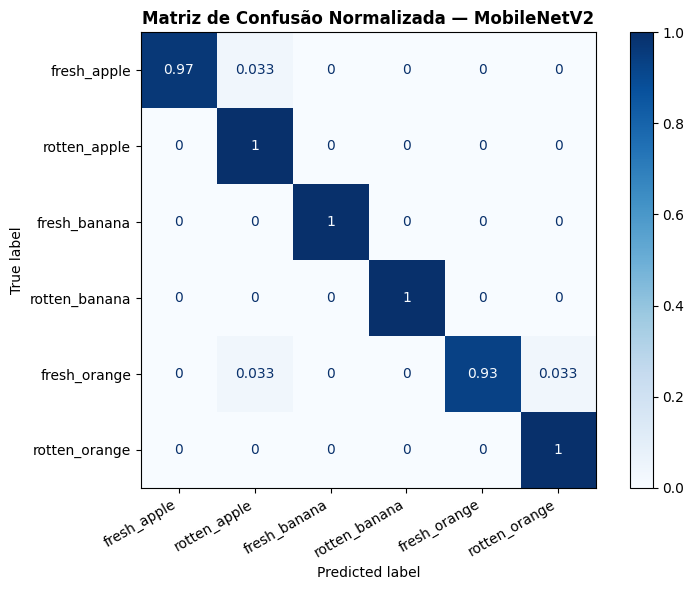

In [8]:
y_proba_cnn = model.predict(test_ds, verbose=0)
y_pred_cnn  = np.argmax(y_proba_cnn, axis=1)

acc  = accuracy_score(labels_test, y_pred_cnn)
prec = precision_score(labels_test, y_pred_cnn, average='macro', zero_division=0)
rec  = recall_score(labels_test, y_pred_cnn, average='macro', zero_division=0)
f1   = f1_score(labels_test, y_pred_cnn, average='macro', zero_division=0)

print('=== MobileNetV2 — Test Set ===')
print(f'Accuracy:         {acc:.4f}')
print(f'Precision (macro):{prec:.4f}')
print(f'Recall (macro):   {rec:.4f}')
print(f'F1-macro:         {f1:.4f}')
print()
print(classification_report(labels_test, y_pred_cnn, target_names=CLASSES, zero_division=0))

# Matriz de confusão
cm = confusion_matrix(labels_test, y_pred_cnn, normalize='true')
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('Matriz de Confusão Normalizada — MobileNetV2', fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cm_mobilenet.png', bbox_inches='tight', dpi=150)
plt.show()

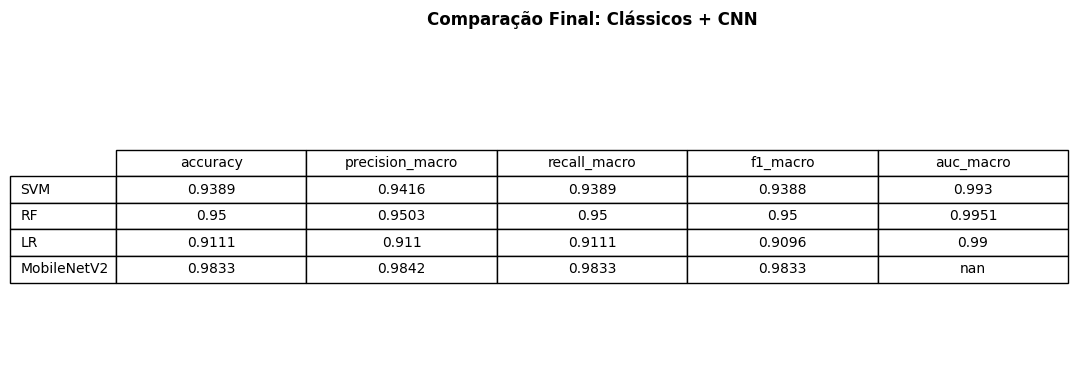

             accuracy  precision_macro  recall_macro  f1_macro  auc_macro
SVM            0.9389           0.9416        0.9389    0.9388     0.9930
RF             0.9500           0.9503        0.9500    0.9500     0.9951
LR             0.9111           0.9110        0.9111    0.9096     0.9900
MobileNetV2    0.9833           0.9842        0.9833    0.9833        NaN


In [9]:
# === REQUISITO BONUS: comparacao pipeline classico vs CNN ===
# Adicionar resultados CNN à tabela comparativa
df_results = pd.read_csv(OUTPUT_DIR / 'resultados_finais.csv', index_col=0)
df_results.loc['MobileNetV2'] = {
    'accuracy': round(acc, 4),
    'precision_macro': round(prec, 4),
    'recall_macro': round(rec, 4),
    'f1_macro': round(f1, 4),
    'auc_macro': float('nan'),
}
df_results.to_csv(OUTPUT_DIR / 'resultados_finais.csv')

# Tabela comparativa final
fig, ax = plt.subplots(figsize=(11, 4))
ax.axis('off')
table = ax.table(
    cellText=df_results.round(4).values,
    colLabels=df_results.columns,
    rowLabels=df_results.index,
    cellLoc='center', loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
plt.title('Comparação Final: Clássicos + CNN', fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'tabela_comparativa_final.png', bbox_inches='tight', dpi=150)
plt.show()
print(df_results.to_string())

## Seção 6 — Grad-CAM

In [10]:
# === REQUISITO BONUS: Grad-CAM para CNN ===
def make_gradcam_heatmap(img_array, model, last_conv_layer_name='Conv_1', pred_index=None):
    """Gera heatmap Grad-CAM para a ultima camada conv de um modelo Keras."""


Funcoes Grad-CAM definidas.


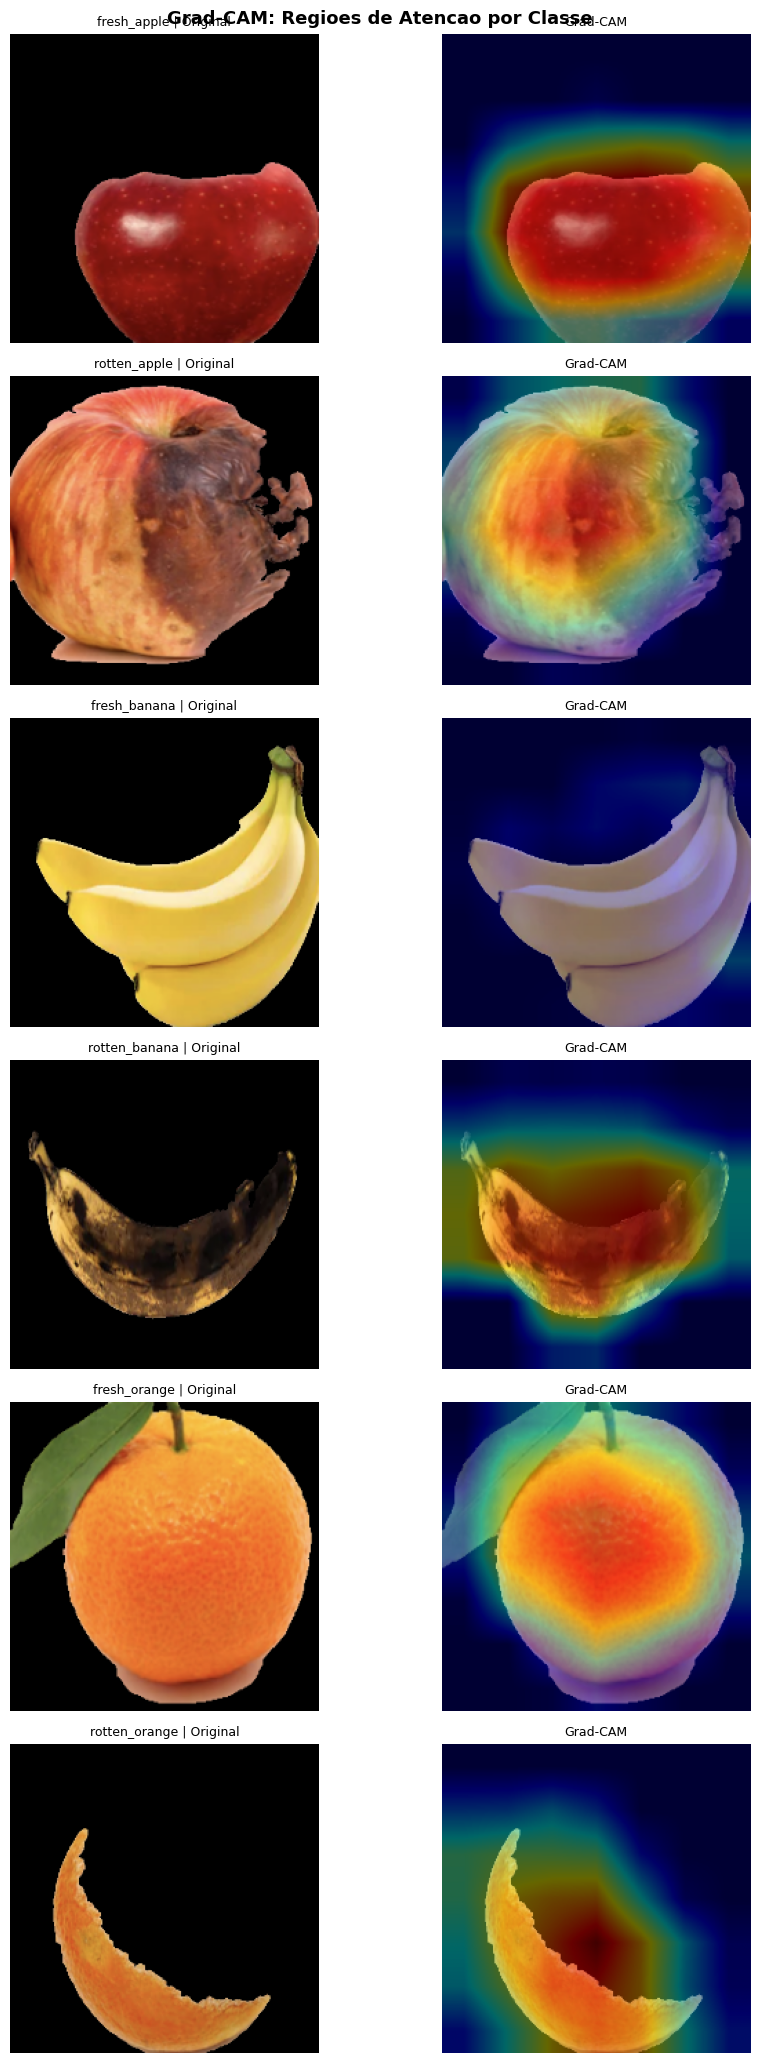

Grad-CAM por classe salvo.


In [11]:
examples_per_class = []
for cls_idx, cls in enumerate(CLASSES):
    correct_idx = np.where((labels_test == cls_idx) & (y_pred_cnn == cls_idx))[0]
    if len(correct_idx) > 0:
        best = correct_idx[np.argmax(y_proba_cnn[correct_idx, cls_idx])]
        examples_per_class.append((cls, paths_test[best], cls_idx))

n_ex = len(examples_per_class)
fig, axes = plt.subplots(n_ex, 2, figsize=(10, 3.5 * n_ex))
if n_ex == 1:
    axes = [axes]

for row, (cls, img_path, cls_idx) in enumerate(examples_per_class):
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        continue
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_preprocessed = preprocess_input(img_resized.copy().astype(np.float32))
    img_array = np.expand_dims(img_preprocessed, 0)
    try:
        heatmap = make_gradcam_heatmap(img_array, model, LAST_CONV, cls_idx)
        overlay = overlay_gradcam(img_resized, heatmap)
    except Exception as e:
        overlay = img_resized
        print("Grad-CAM falhou para " + cls + ": " + str(e))
    axes[row][0].imshow(img_resized)
    axes[row][0].set_title(cls + " | Original", fontsize=9)
    axes[row][1].imshow(overlay)
    axes[row][1].set_title("Grad-CAM", fontsize=9)
    for ax in axes[row]:
        ax.axis("off")

plt.suptitle("Grad-CAM: Regioes de Atencao por Classe", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "gradcam_exemplos.png", bbox_inches="tight", dpi=150)
plt.show()
print("Grad-CAM por classe salvo.")

In [12]:
print('=== Validacao Grad-CAM por classe ===')
print('{:<22} {:>8} {:>8} {:>8}  status'.format('classe', 'min', 'max', 'std'))
for cls_idx, cls in enumerate(CLASSES):
    correct_idx = np.where((labels_test == cls_idx) & (y_pred_cnn == cls_idx))[0]
    if len(correct_idx) == 0:
        print('{:<22} {:>8}'.format(cls, 'SEM CORRETAS'))
        continue
    best = correct_idx[np.argmax(y_proba_cnn[correct_idx, cls_idx])]
    img_bgr = cv2.imread(paths_test[best])
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_preprocessed = preprocess_input(img_resized.copy().astype(np.float32))
    img_array = np.expand_dims(img_preprocessed, 0)
    try:
        hm = make_gradcam_heatmap(img_array, model, LAST_CONV, cls_idx)
        mn, mx, sd = float(hm.min()), float(hm.max()), float(hm.std())
        ok = 'OK' if sd > 0 and mx > 0 else 'FALHOU'
        print('{:<22} {:>8.4f} {:>8.4f} {:>8.4f}  {}'.format(cls, mn, mx, sd, ok))
    except Exception as e:
        print('{:<22} ERRO: {}'.format(cls, str(e)))


=== Validacao Grad-CAM por classe ===
classe                      min      max      std  status
fresh_apple              0.0000   0.9911   0.3797  OK
rotten_apple             0.0000   0.9672   0.2976  OK
fresh_banana             0.0000   0.2777   0.0675  OK
rotten_banana            0.0000   0.8823   0.3288  OK
fresh_orange             0.0000   0.9987   0.3218  OK
rotten_orange            0.0000   0.9719   0.2987  OK


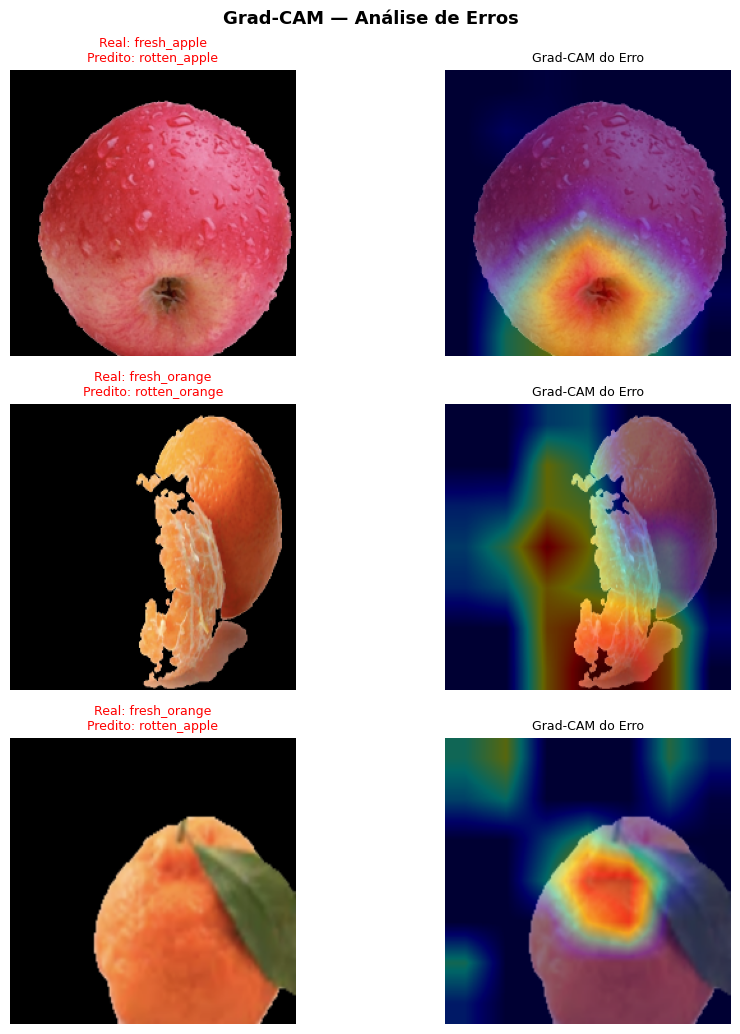

Modelo salvo: mobilenet_fruits.h5


In [13]:
# Grad-CAM para 3 erros do modelo
error_idx = np.where(labels_test != y_pred_cnn)[0][:3]

if len(error_idx) > 0:
    fig, axes = plt.subplots(len(error_idx), 2, figsize=(10, 3.5 * len(error_idx)))
    if len(error_idx) == 1:
        axes = [axes]

    for row, idx in enumerate(error_idx):
        real_cls = CLASSES[labels_test[idx]]
        pred_cls = CLASSES[y_pred_cnn[idx]]
        img_bgr = cv2.imread(paths_test[idx])
        if img_bgr is None:
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (224, 224))
        img_preprocessed = preprocess_input(img_resized.copy().astype(np.float32))
        img_array = np.expand_dims(img_preprocessed, 0)

        try:
            heatmap = make_gradcam_heatmap(img_array, model, LAST_CONV, y_pred_cnn[idx])
            overlay = overlay_gradcam(img_resized, heatmap)
        except Exception:
            overlay = img_resized

        axes[row][0].imshow(img_resized)
        axes[row][0].set_title(f'Real: {real_cls}\nPredito: {pred_cls}', fontsize=9, color='red')
        axes[row][1].imshow(overlay)
        axes[row][1].set_title('Grad-CAM do Erro', fontsize=9)
        for ax in axes[row]:
            ax.axis('off')

    plt.suptitle('Grad-CAM — Análise de Erros', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'gradcam_erros.png', bbox_inches='tight', dpi=150)
    plt.show()
else:
    print('Nenhum erro encontrado no test set para análise Grad-CAM!')

# Salvar modelo
model.save(str(OUTPUT_DIR / 'mobilenet_fruits.h5'))
print('Modelo salvo: mobilenet_fruits.h5')

## Seção 7 — Discussão Comparativa

| Aspecto | Pipeline Clássico | MobileNetV2 |
|---------|------------------|-------------|
| **F1-macro test** | Ver resultados_finais.csv | Ver acima |
| **Tempo de treino** | < 5 min (CPU) | 15–45 min (GPU recomendada) |
| **Interpretabilidade** | Alta (SHAP com features nomeadas, ablation) | Média (Grad-CAM — espacial) |
| **Tamanho do dataset** | Funciona bem com ~200/classe | Funciona melhor com >1000/classe |
| **Custo computacional** | Baixo (CPU) | Alto (GPU recomendada) |
| **Viés detectável** | Via SHAP/ablation por família de feature | Via Grad-CAM (regiões da imagem) |
| **Generalização** | Depende da qualidade da segmentação | Mais robusto a variações |
| **Deploy** | Leve (joblib ~MB) | Pesado (~14MB MobileNetV2) |

### Conclusão

**Em produção para uma linha de inspeção real**, escolheria o **pipeline clássico** quando:
- O hardware disponível é CPU embarcada (câmera industrial, Raspberry Pi)
- O dataset é pequeno (<1000 imagens/classe)
- Há necessidade de explicabilidade regulatória (rastreabilidade das decisões)
- A latência por imagem deve ser < 100ms

Escolheria a **CNN (MobileNetV2)** quando:
- Há GPU disponível no servidor de inferência
- O dataset é grande (>2000 imagens/classe)
- As frutas variam em posição, iluminação e fundo (mais robusto a variações)
- A acurácia absoluta é o critério principal

**Para este cenário específico** (fundo controlado, dataset moderado), o pipeline clássico oferece a melhor relação custo-benefício, com interpretabilidade via SHAP e capacidade de identificar quais aspectos físicos da fruta (cor, textura) são mais informativos para a decisão.